In [1]:
# %% [markdown]
# # AZMB / Pyrolysis Elsevier 메타데이터 클리닝 노트북
# - URL 기준 중복 제거
# - 제목 길이/패턴 기반 비유효값 제거
# - XML/Math 태그 제거 후 title_clean 생성
# - 정제 전/후 title 길이 분포 시각화
# - 최종 cleaned CSV 저장

# %% [code]
import os
import re
import logging
from textwrap import dedent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# tqdm + pandas 연동 (apply 시 진행률 표시)
tqdm.pandas()

# -----------------------------
# Matplotlib / Seaborn 설정
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")
sns.set(font_scale=1.1)

# -----------------------------
# Logging 설정
# -----------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler("data_cleaning.log", encoding="utf-8"),
        logging.StreamHandler()
    ],
)

logging.info("=== AZMB / Pyrolysis 메타데이터 정제 노트북 시작 ===")


c:\Users\PSID_PC_20\anaconda3\envs\acetylene_converter\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-05 17:15:20,207 | INFO | === AZMB / Pyrolysis 메타데이터 정제 노트북 시작 ===


In [3]:
# %% [markdown]
# ## 1. 입력 경로 및 컬럼 정보 설정

# %% [code]
# === 사용자 설정 부분 ===
INPUT_CSV = "combined.csv"   # <-- 여기에 combined CSV 이름 넣기
OUTPUT_DIR = "./cleaned_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# URL / TITLE 컬럼 이름 (데이터셋에 맞게 바꾸면 됨)
URL_COL = "url"        # 예: 'url', 'prism_url' 등
TITLE_COL = "title"    # 보통 'title'

logging.info(f"INPUT_CSV: {INPUT_CSV}")
logging.info(f"URL_COL  : {URL_COL}")
logging.info(f"TITLE_COL: {TITLE_COL}")

# %% [code]
# CSV 로드
logging.info("원본 CSV 로드 시작")
DF_raw = pd.read_csv(INPUT_CSV)
logging.info(f"원본 DF shape: {DF_raw.shape}")

# 필수 컬럼 체크
missing_cols = [col for col in [URL_COL, TITLE_COL] if col not in DF_raw.columns]
if missing_cols:
    raise ValueError(f"필수 컬럼이 존재하지 않습니다: {missing_cols}")
else:
    logging.info("필수 컬럼(URL, TITLE) 모두 존재 확인 완료")


2025-12-05 17:15:29,113 | INFO | INPUT_CSV: combined.csv
2025-12-05 17:15:29,113 | INFO | URL_COL  : url
2025-12-05 17:15:29,114 | INFO | TITLE_COL: title
2025-12-05 17:15:29,115 | INFO | 원본 CSV 로드 시작
2025-12-05 17:15:29,750 | INFO | 원본 DF shape: (196000, 3)
2025-12-05 17:15:29,754 | INFO | 필수 컬럼(URL, TITLE) 모두 존재 확인 완료


In [4]:
# %% [markdown]
# ## 2. URL 기준 중복 제거

# %% [code]
before_n = len(DF_raw)
DF_dropdu = DF_raw.drop_duplicates(subset=[URL_COL]).reset_index(drop=True)
after_n = len(DF_dropdu)

logging.info(f"URL 기준 drop_duplicates: {before_n} → {after_n} (제거 {before_n - after_n})")

print(f"URL 기준 중복 제거 전: {before_n:,}")
print(f"URL 기준 중복 제거 후: {after_n:,}")
print(f"제거된 중복 수      : {before_n - after_n:,}")


2025-12-05 17:15:31,460 | INFO | URL 기준 drop_duplicates: 196000 → 2720 (제거 193280)


URL 기준 중복 제거 전: 196,000
URL 기준 중복 제거 후: 2,720
제거된 중복 수      : 193,280


In [5]:
# %% [markdown]
# ## 3. 제목 길이 기반 비유효값 제거 (길이 < 25)

# %% [code]
# title_length 계산
DF_dropdu["title_length"] = DF_dropdu[TITLE_COL].apply(lambda x: len(str(x)))

logging.info("제목 길이가 25 미만인 샘플 일부 확인")

short_titles = DF_dropdu.loc[DF_dropdu["title_length"] < 25, [TITLE_COL, "title_length"]]
print("=== 길이 < 25 제목 예시 (상위 50개) ===")
display(short_titles.head(50))

# 필터링
DF_v2 = DF_dropdu[DF_dropdu["title_length"] >= 25].copy()
removed_short = len(DF_dropdu) - len(DF_v2)

logging.info(f"길이 < 25 제목 제거: {removed_short} / {len(DF_dropdu)}")
print(f"\n제거된 개수 (길이 < 25): {removed_short}")
print(f"필터링 후 데이터 수     : {len(DF_v2)}")


2025-12-05 17:15:43,992 | INFO | 제목 길이가 25 미만인 샘플 일부 확인


=== 길이 < 25 제목 예시 (상위 50개) ===


,title,title_length
1057,Index,5
1063,Graphical Abstracts,19
1065,Abstracts,9
1066,Abstracts,9
1068,Abstracts,9
1069,Index,5
1070,Abstracts,9
1071,Index,5
1075,Abstracts,9
1077,Abstracts,9


2025-12-05 17:15:44,014 | INFO | 길이 < 25 제목 제거: 18 / 2720



제거된 개수 (길이 < 25): 18
필터링 후 데이터 수     : 2702


In [6]:
# %% [markdown]
# ## 4. 제목에 '|' 포함된 행 제거

# %% [code]
pipe_mask = DF_v2[TITLE_COL].astype(str).str.contains(r"\|", na=False)
pipe_count = pipe_mask.sum()

logging.info(f"'|' 포함 제목 개수: {pipe_count}")
print(f"'|' 포함 제목 개수: {pipe_count}")

if pipe_count > 0:
    print("\n'|' 포함된 제목 예시:")
    display(DF_v2.loc[pipe_mask, [TITLE_COL]].head(20))

DF_v3 = DF_v2[~pipe_mask].copy()
logging.info(f"'|' 포함 행 제거 후 shape: {DF_v3.shape}")
print(f"\n제거 후 데이터 수: {len(DF_v3)}")


2025-12-05 17:15:48,948 | INFO | '|' 포함 제목 개수: 8


'|' 포함 제목 개수: 8

'|' 포함된 제목 예시:


,title
485,Stabilizing electrolytic Zn||MnO<ce:inf loc=po...
718,Enhancing reversibility of zinc metal for Zn||...
869,Lithium Batteries – Lithium Secondary Batterie...
906,Batteries – Battery Types – Zinc Batteries | Z...
931,Lithium Batteries – Lithium Secondary Batterie...
1046,Batteries – Battery Types – Lithium Batteries ...
1426,Batteries – Battery Types – Zinc Batteries | Z...
2648,Lithium Batteries – Lithium Secondary Batterie...


2025-12-05 17:15:48,955 | INFO | '|' 포함 행 제거 후 shape: (2694, 4)



제거 후 데이터 수: 2694


2025-12-05 17:15:54,919 | INFO | === Z-score (raw title_length) ===
2025-12-05 17:15:54,920 | INFO | mean: 119.950, std: 38.169
2025-12-05 17:15:54,921 | INFO | lower_bound(Z=-3): 5.444, upper_bound(Z=+3): 234.455


==== Z-score Threshold Info (raw title_length) ====
mean title_length       : 119.95
std title_length        : 38.17
lower bound (Z=-3)      : 5.44
upper bound (Z=+3)      : 234.46

Total outliers (raw): 36
Total normal   (raw): 2658


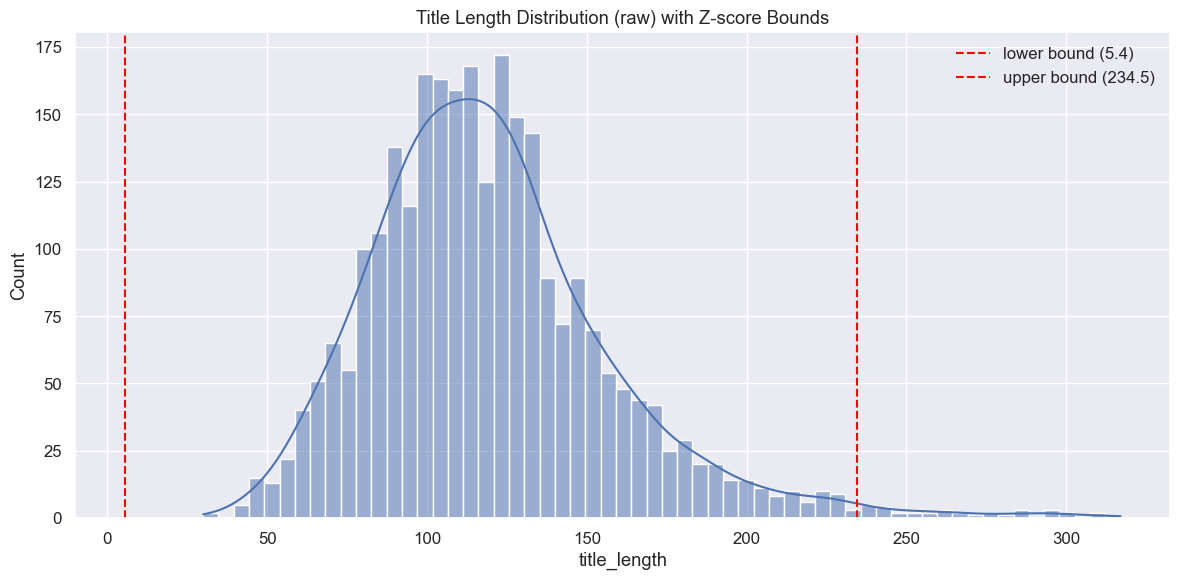


=== raw outlier titles (상위 10개) ===


,title,title_length
267,Simultaneous manipulation of electron/Zn<ce:su...,240
346,Defective ZnO<ce:inf loc=post>x</ce:inf>@porou...,297
370,Developing a high-performance aqueous zinc bat...,250
409,Nanoporous core–shell–structured multi-wall ca...,238
510,<ce:italic>In situ</ce:italic> growth of Mn<ce...,260
636,<ce:italic>In-situ</ce:italic> etching and ion...,260
876,<ce:italic>In-situ</ce:italic> formation of ca...,295
982,High-entropy strategy to suppress volumetric s...,298
1130,Mn<ce:sup loc=post>2+</ce:sup>/H<ce:sup loc=po...,296
1149,Cr<ce:inf loc=post>2</ce:inf>O<ce:inf loc=post...,265


In [7]:
# %% [markdown]
# ## 5. 정제 전 제목 길이 분포 & Z-score 기반 이상치 탐색 (1차)

# %% [code]
# Z-score 계산
mean_val = DF_v3["title_length"].mean()
std_val = DF_v3["title_length"].std()

DF_v3["zscore_raw"] = (DF_v3["title_length"] - mean_val) / std_val
threshold = 3.0

lower_bound = mean_val - threshold * std_val
upper_bound = mean_val + threshold * std_val

logging.info("=== Z-score (raw title_length) ===")
logging.info(f"mean: {mean_val:.3f}, std: {std_val:.3f}")
logging.info(f"lower_bound(Z=-3): {lower_bound:.3f}, upper_bound(Z=+3): {upper_bound:.3f}")

print("==== Z-score Threshold Info (raw title_length) ====")
print(f"mean title_length       : {mean_val:.2f}")
print(f"std title_length        : {std_val:.2f}")
print(f"lower bound (Z=-3)      : {lower_bound:.2f}")
print(f"upper bound (Z=+3)      : {upper_bound:.2f}")

outliers_raw = DF_v3[DF_v3["zscore_raw"].abs() >= threshold]
normal_raw = DF_v3[DF_v3["zscore_raw"].abs() < threshold]

print(f"\nTotal outliers (raw): {len(outliers_raw)}")
print(f"Total normal   (raw): {len(normal_raw)}")

# 히스토그램
plt.figure(figsize=(12, 6))
sns.histplot(DF_v3["title_length"], bins=60, kde=True)
plt.axvline(lower_bound, color="red", linestyle="--", label=f"lower bound ({lower_bound:.1f})")
plt.axvline(upper_bound, color="red", linestyle="--", label=f"upper bound ({upper_bound:.1f})")
plt.title("Title Length Distribution (raw) with Z-score Bounds")
plt.xlabel("title_length")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== raw outlier titles (상위 10개) ===")
display(outliers_raw[[TITLE_COL, "title_length"]].head(10))


In [8]:
# %% [markdown]
# ## 6. XML/Math 태그 제거 후 title_clean 생성

# %% [code]
TAG_PATTERN = re.compile(r"<[^>]+>")

def clean_title(text: str) -> str:
    """
    Elsevier XML 메타데이터에서 넘어온 <ce:inf>, <ce:italic>, <ce:anchor> 등의
    태그를 모두 제거하고, 공백을 정리하여 깔끔한 title 문자열을 반환.
    """
    if pd.isna(text):
        return ""
    s = str(text)
    # 1) <...> 태그 제거
    s = TAG_PATTERN.sub("", s)
    # 2) 여러 공백을 하나로
    s = re.sub(r"\s+", " ", s).strip()
    return s

logging.info("title_clean 생성 시작 (태그 제거)")
DF_v3["title_clean"] = DF_v3[TITLE_COL].progress_apply(clean_title)
DF_v3["title_length_clean"] = DF_v3["title_clean"].str.len()

logging.info("title_clean 생성 완료")
print("title_clean / title_length_clean 예시:")
display(DF_v3[[TITLE_COL, "title_clean", "title_length", "title_length_clean"]].head(10))


2025-12-05 17:16:02,638 | INFO | title_clean 생성 시작 (태그 제거)
100%|██████████| 2694/2694 [00:00<00:00, 96126.31it/s]
2025-12-05 17:16:02,712 | INFO | title_clean 생성 완료


title_clean / title_length_clean 예시:


,title,title_clean,title_length,title_length_clean
0,Artificial protective layers of zinc metal ano...,Artificial protective layers of zinc metal ano...,91,91
1,A stable zinc anode with a hardwood kraft lign...,A stable zinc anode with a hardwood kraft lign...,146,146
2,Achieving stable Zn anode via artificial inter...,Achieving stable Zn anode via artificial inter...,113,113
3,Biomimetic behavior at the interphase of zinc-...,Biomimetic behavior at the interphase of zinc-...,88,88
4,An artificial layer structure-modulated “high ...,An artificial layer structure-modulated “high ...,109,109
5,Superabsorbent starch protective layer modulat...,Superabsorbent starch protective layer modulat...,110,110
6,Realization of protective-layer-free Zn anode ...,Realization of protective-layer-free Zn anode ...,138,138
7,The ZnMoO<ce:inf loc=post>4</ce:inf>/Mo<ce:inf...,The ZnMoO4/MoxOy metal-oxygen clusters for the...,201,123
8,Nitrogen-coordinated iron single atoms porous ...,Nitrogen-coordinated iron single atoms porous ...,170,170
9,Elaborate artificial construction of porous bi...,Elaborate artificial construction of porous bi...,156,156


In [9]:
DF_v3.to_csv("ARTICEL_SEARCH_RESULT.csv", index=False, encoding="utf-8-sig")